<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/Titanic3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report, roc_auc_score,roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
pd.DataFrame({'data_type':df.dtypes,'unique_values':df.nunique()})

,data_type,unique_values
PassengerId,int64,891
Survived,int64,2
Pclass,int64,3
Name,object,891
Sex,object,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Ticket,object,681
Fare,float64,248


In [6]:
df.drop(['PassengerId','Cabin','Name'],axis=1,inplace=True)

In [7]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [9]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [10]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [12]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [13]:
pd.DataFrame({'data_types':df.dtypes,'unique_values':df.nunique()})

,data_types,unique_values
Survived,int64,2
Pclass,int64,3
Sex,object,2
Age,float64,89
SibSp,int64,7
Parch,int64,7
Ticket,object,681
Fare,float64,248
Embarked,object,3


In [14]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


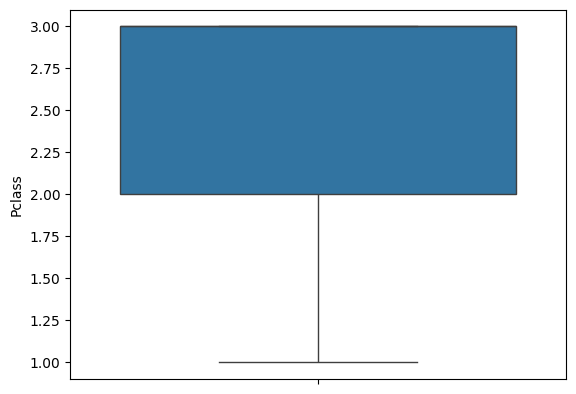

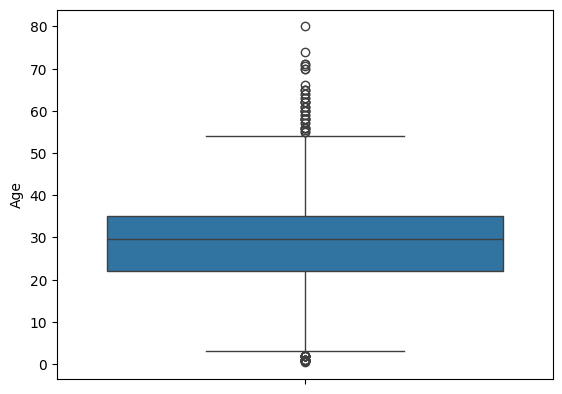

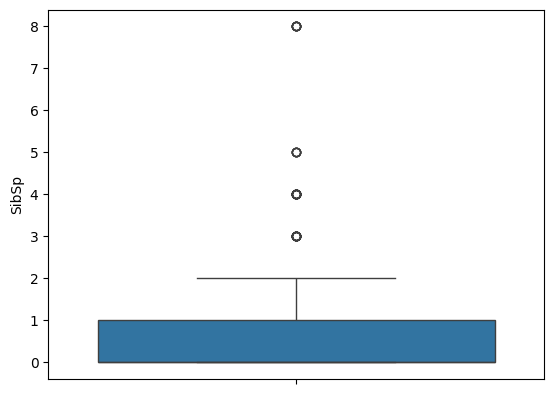

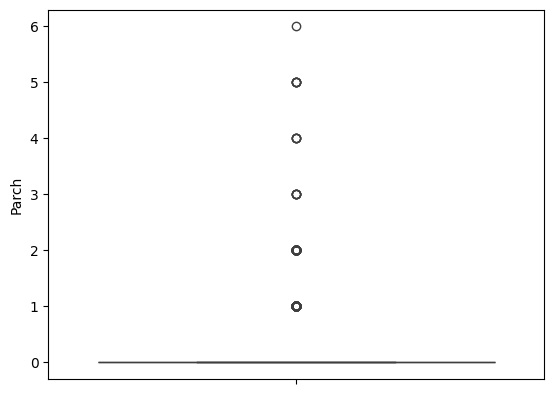

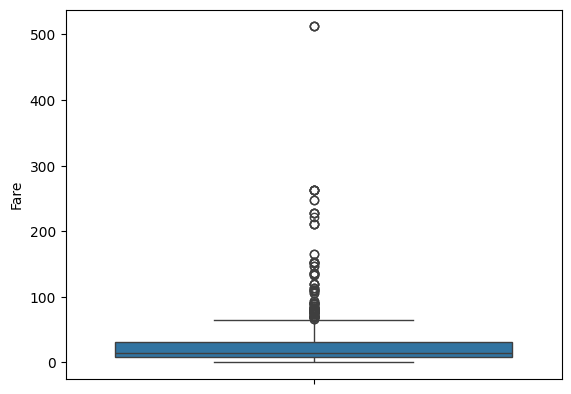

In [15]:
s=['Pclass','Age','SibSp','Parch','Fare']

for i in s:
  sns.boxplot(df[i])
  plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


In [18]:
df['Age'].min()

0.42

In [19]:
num=df[['Pclass','Age','SibSp','Parch','Fare']]
Q1=num.quantile(0.25)
Q3=num.quantile(0.75)

IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

lower_outliers=num<lower_bound
upper_outliers=num>upper_bound

In [20]:
print(lower_bound)

Pclass     0.500
Age        2.500
SibSp     -1.500
Parch      0.000
Fare     -26.724
dtype: float64


In [21]:
print(lower_outliers.sum())

Pclass     0
Age       24
SibSp      0
Parch      0
Fare       0
dtype: int64


In [22]:
print(upper_outliers.sum())

Pclass      0
Age        42
SibSp      46
Parch     213
Fare      116
dtype: int64


In [23]:
s = ['Age', 'SibSp', 'Parch', 'Fare']

for i in s:
    lb = lower_bound[i]
    ub = upper_bound[i]
    df[i] = df[i].clip(lower=lb, upper=ub)

In [24]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.0,891.000000
mean,0.383838,2.308642,29.376817,0.426487,0.0,24.046813
std,0.486592,0.836071,12.062035,0.708246,0.0,20.481625
min,0.000000,1.000000,2.500000,0.000000,0.0,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.0,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.0,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.0,31.000000
max,1.000000,3.000000,54.500000,2.500000,0.0,65.634400


In [25]:
df.drop(['Ticket'],axis=1,inplace=True)

In [26]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [27]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [28]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [29]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FarePerPerson
0,0,3,male,22.0,1.0,0,7.2500,S,2.0,0,3.6250
1,1,1,female,38.0,1.0,0,65.6344,C,2.0,0,32.8172
2,1,3,female,26.0,0.0,0,7.9250,S,1.0,1,7.9250
3,1,1,female,35.0,1.0,0,53.1000,S,2.0,0,26.5500
4,0,3,male,35.0,0.0,0,8.0500,S,1.0,1,8.0500


In [30]:
s=['Sex','Embarked']
for i in s:
  print(df[i].value_counts(),'\n')

Sex
male      577
female    314
Name: count, dtype: int64 

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64 



In [31]:
df.drop(['SibSp','Parch'],axis=1,inplace=True)

In [32]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
Fare,float64
Embarked,object
FamilySize,float64
IsAlone,int64
FarePerPerson,float64


In [33]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [34]:
df['Sex'].value_counts()

,count
Sex,
1,577
0,314


In [35]:
df=pd.get_dummies(df,columns=['Embarked'], drop_first=True)

In [36]:
X=df.drop(['Survived'],axis=1)
y=df['Survived']

In [37]:
sc=StandardScaler()
X_Scaled=sc.fit_transform(X)

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X_Scaled,y,test_size=0.2,random_state=1,stratify=y)

In [39]:
y_train.value_counts()

,count
Survived,
0,439
1,273


In [40]:
y_test.value_counts()

,count
Survived,
0,110
1,69


In [41]:
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [42]:
y_pred_train=lg.predict(X_train)
y_pred_test=lg.predict(X_test)

In [43]:
accuracy_score(y_test,y_pred_test)

0.8156424581005587

In [44]:
accuracy_score(y_train,y_pred_train)

0.8132022471910112

In [45]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [46]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       439
           1       0.77      0.73      0.75       273

    accuracy                           0.81       712
   macro avg       0.80      0.80      0.80       712
weighted avg       0.81      0.81      0.81       712



In [47]:
cross_val_score(lg,X_train,y_train,cv=10).mean()

np.float64(0.8019170579029733)


    key rules for kfold cv:
    Agar train_acc.mean() ≫ test_acc → model may be overfitting
	•	Agar train_acc.mean() ≪ test_acc → kuch gadbad! (maybe data leakage?)
	•	Agar dono similar → 🎯 well-trained model

    train_accuracy mean: 0.7949334898278562

    normal test accuracy: 0.7932960893854749

    hence: we can that it is well trained model

In [48]:
print('\n',classification_report(y_test,y_pred_test))


               precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [49]:
X_train.shape

(712, 9)

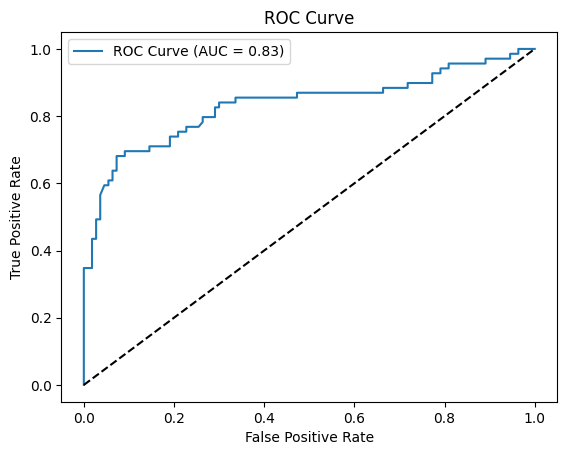

In [57]:
y_probs = lg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [59]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

print("Best Threshold (by Youden's J):", best_threshold)

Best Threshold (by Youden's J): 0.581599720146631


	•	Agar false positives zyada dangerous hain (e.g. cancer diagnosis) → choose threshold with low FPR
	•	Agar false negatives zyada dangerous hain (e.g. fraud detection) → choose threshold with high TPR

    AUC of 0.5 indicates that the model’s performance is comparable to that of random chance.
    It suggests a lack of discriminating ability.

    Jaise threshold value decrease hoti hai (third array), TPR aur FPR dono increase hote hain
    Lowest threshold par, TPR aur FPR dono 1 hote hain (sab kuch positive predict karta hai)
    Highest threshold par, TPR aur FPR dono 0 hote hain (kuch bhi positive predict nahi karta)

    ROC curve mein har point ek trade-off represent karta hai:
    kitne true positives catch karne ke liye aap kitne false positives accept karne ko taiyar hain.

    Low threshold: More sensitive but less specific (TPR high, FPR also high)
    High threshold: Less sensitive but more specific (TPR low, FPR also low)

    lg.predict proba se jo probabilities humko milti h
    roc curve unhi probabilties ko pehle unique krke as threshold bana ke
    tpr aur fpr ka balance combination nikalta h descending order me

    Maanlo 0.65 threshold pr TPR aur FPR ka sahi balance ho, to
    ROC curve me AUC line (diagonal) aur curve ke beech sabse zyada gap wahi hoga

In [55]:
y_test.shape

(179,)

In [53]:
X_test.shape

(179, 9)

In [51]:
roc_curve(y_test, y_probs)

(array([0.        , 0.        , 0.        , 0.        , 0.01818182,
        0.01818182, 0.02727273, 0.02727273, 0.03636364, 0.03636364,
        0.03636364, 0.04545455, 0.05454545, 0.05454545, 0.06363636,
        0.06363636, 0.07272727, 0.07272727, 0.09090909, 0.09090909,
        0.14545455, 0.14545455, 0.19090909, 0.19090909, 0.20909091,
        0.20909091, 0.22727273, 0.22727273, 0.25454545, 0.26363636,
        0.26363636, 0.29090909, 0.29090909, 0.3       , 0.3       ,
        0.33636364, 0.33636364, 0.36363636, 0.47272727, 0.47272727,
        0.5       , 0.52727273, 0.57272727, 0.59090909, 0.66363636,
        0.66363636, 0.71818182, 0.71818182, 0.77272727, 0.77272727,
        0.79090909, 0.79090909, 0.80909091, 0.80909091, 0.83636364,
        0.89090909, 0.89090909, 0.94545455, 0.94545455, 0.96363636,
        0.96363636, 1.        ]),
 array([0.        , 0.01449275, 0.04347826, 0.34782609, 0.34782609,
        0.43478261, 0.43478261, 0.49275362, 0.49275362, 0.53623188,
        0.5652

	•	0.91145017 → probability that this person did NOT survive (class 0)
	•	0.08854983 → probability that this person DID survive (class 1)

In [52]:
lg.predict_proba(X_test)[:,1]

array([0.07856578, 0.31431736, 0.20664946, 0.3619249 , 0.09839445,
       0.10352113, 0.10637886, 0.43394547, 0.30864287, 0.12133675,
       0.90409339, 0.42817488, 0.46573868, 0.04495721, 0.9410011 ,
       0.26277211, 0.13050246, 0.84146246, 0.75644179, 0.30864287,
       0.11644708, 0.09044665, 0.89466182, 0.03125069, 0.14292548,
       0.09604996, 0.83834047, 0.64688689, 0.0852443 , 0.23175785,
       0.08046325, 0.21764858, 0.71571255, 0.79704346, 0.0806087 ,
       0.66539695, 0.01937488, 0.09442831, 0.6205281 , 0.1032334 ,
       0.11489559, 0.73014123, 0.08038578, 0.05586284, 0.80468258,
       0.87782078, 0.9198948 , 0.14289749, 0.20375542, 0.67381152,
       0.09438228, 0.13014955, 0.03879219, 0.56568228, 0.04695996,
       0.05166147, 0.6601815 , 0.97583466, 0.4293154 , 0.67381152,
       0.13050246, 0.44542837, 0.69517336, 0.08665942, 0.8173838 ,
       0.11346743, 0.86636567, 0.48838423, 0.73614027, 0.35828658,
       0.93778084, 0.84648073, 0.20664946, 0.56057103, 0.85579

In [54]:
y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

    predict proba k andar pehle prediction probalities store hoti h by
    lg.predict_proba(X_test)
    lg.predict(X_test) se 0 aur 1 me wo classify ho jaata h

    phir usko threshold default:0.5 k basis pr 0 ya 1 class me classify kiya jaata h

    Medical field me galti ki gunjaish kam rakhni hai,
    isliye threshold kam (e.g. 0.3 ya 0.4) rakh sakte hoon taaki false negative pakad me aaye
    threshold customize bhi kr skte h apne hisab se, taaki predictions accurate ho

    Best Practice in Medical AI:
	•	Low threshold = High Recall (Sensitivity)
    “Jitne bhi cancer ke suspects hain, sabko pakdo”
	•	Phir specialist confirm karega final result

In [55]:
y_prob_test = lg.predict_proba(X_test)[:, 1]
threshold = 0.2
y_pred_c_test = (y_prob_test >= threshold).astype(int)

In [56]:
y_prob_train = lg.predict_proba(X_train)[:, 1]
threshold = 0.3
y_pred_c_train = (y_prob_train >= threshold).astype(int)

In [57]:
print(classification_report(y_test,y_pred_c_test))

              precision    recall  f1-score   support

           0       0.87      0.63      0.73       110
           1       0.59      0.86      0.70        69

    accuracy                           0.72       179
   macro avg       0.73      0.74      0.71       179
weighted avg       0.76      0.72      0.72       179



In [58]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [59]:
accuracy_score(y_train,y_pred_c_train)

0.7752808988764045

In [60]:
accuracy_score(y_test,y_pred_c_test)

0.7150837988826816

In [61]:
accuracy_score(y_test,y_pred_test)

0.8156424581005587

In [62]:
accuracy_score(y_train,y_pred_train)

0.8132022471910112

    New features create karein jo survival patterns better capture karein

In [63]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [64]:
y_rf_train=rf.predict(X_train)
y_rf_test=rf.predict(X_test)

In [65]:
print(classification_report(y_test,y_rf_test))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [66]:
print(classification_report(y_train,y_rf_train))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       439
           1       0.98      0.96      0.97       273

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [67]:
accuracy_score(y_train,y_rf_train)

0.9789325842696629

In [68]:
accuracy_score(y_test,y_rf_test)

0.8044692737430168

In [69]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [70]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       439
           1       0.77      0.73      0.75       273

    accuracy                           0.81       712
   macro avg       0.80      0.80      0.80       712
weighted avg       0.81      0.81      0.81       712



In [71]:
accuracy_score(y_test,y_pred_test)

0.8156424581005587

In [72]:
accuracy_score(y_train,y_pred_train)

0.8132022471910112

In [73]:
xgb=XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [74]:
y_pred_xg_train=xgb.predict(X_train)
y_pred_xg_test=xgb.predict(X_test)

In [75]:
accuracy_score(y_test,y_pred_xg_test)

0.8324022346368715

In [76]:
accuracy_score(y_train,y_pred_xg_train)

0.9676966292134831

In [77]:
print(classification_report(y_test,y_pred_xg_test))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       110
           1       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [78]:
print(classification_report(y_train,y_pred_xg_train))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       439
           1       0.97      0.95      0.96       273

    accuracy                           0.97       712
   macro avg       0.97      0.96      0.97       712
weighted avg       0.97      0.97      0.97       712

